# Macroeconomic Shock Propagation in India
## VAR-Based Inflation Forecasting with Granger Causality and ML Benchmarking

This notebook models the dynamic relationships between India's key macroeconomic indicators — GDP growth, CPI inflation, unemployment, and lending interest rates — using a VAR framework (World Bank WDI data, 1990–2023). We then benchmark the VAR forecast against XGBoost to understand what a purely data-driven approach gains or loses relative to a structured econometric model.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import shap

sns.set_style('whitegrid')
sns.set_palette('muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## 1. Data Loading & Preprocessing

In [2]:
raw = pd.read_csv('tdata.csv')
print(f'Raw shape: {raw.shape}')
raw.head(5)

Raw shape: (9, 40)


,Country Name,Country Code,Series Name,Series Code,1990 [YR1990],1991 [YR1991],1992 [YR1992],1993 [YR1993],1994 [YR1994],1995 [YR1995],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,India,IND,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,5.53345456125301,1.056831,5.482396,4.750776,6.658924,7.574492,...,8.256306,6.795383,6.453851,3.871437,-5.777725,9.689592,7.609365,9.19075493028345,6.49476552383821,..
1,India,IND,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,8.9712325027325,13.870246,11.787817,6.326890,10.247936,10.224886,...,4.948216,3.328173,3.938826,3.729506,6.623437,5.131407,6.699034,5.64914318907925,4.95303550973656,..
2,India,IND,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,..,7.641000,7.649000,7.662000,7.593000,7.570000,...,7.611000,7.626000,7.652000,6.510000,7.859000,6.380000,4.822000,4.172,4.173,4.219
3,India,IND,Lending interest rate (%),FR.INR.LEND,16.5,17.875000,18.916667,16.250000,14.750000,15.458333,...,9.672500,9.508333,9.454167,9.466250,9.150000,8.698333,8.567143,..,..,..
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# WDI format: each row is one indicator series, each column is a year.
# Filter to India rows only, then transpose so years become the index.

india = raw[raw['Country Code'] == 'IND'].copy()

# Year columns are named like '1990 [YR1990]'
year_cols = [c for c in india.columns if c[:2] in ('19', '20')]

df = india.set_index('Series Name')[year_cols].T.copy()
df.index = [int(c.split(' ')[0]) for c in df.index]
df.index.name = 'year'

# WDI uses '..' for missing — replace before converting to float
df = df.replace('..', np.nan).astype(float)

df.columns = ['gdp_growth', 'cpi', 'unemp', 'lending_rate']

# 2024-2025 are mostly NaN (data not yet released)
df = df[df.index <= 2023]

print(f'Series: {int(df.index.min())}–{int(df.index.max())}  ({len(df)} observations)')
print(f'\nMissing values:\n{df.isnull().sum()}')

Series: 1990–2023  (34 observations)

Missing values:
gdp_growth      0
cpi             0
unemp           1
lending_rate    1
dtype: int64


In [4]:
# Forward fill first, then linear interpolation for any interior gaps
df = df.ffill().interpolate(method='linear')

print('Missing after imputation:', df.isnull().sum().sum())
df.describe().round(2)

Missing after imputation: 1


,gdp_growth,cpi,unemp,lending_rate
count,34.00,34.00,33.00,34.00
mean,6.11,7.14,7.36,11.98
std,2.88,3.06,0.80,2.83
min,-5.78,3.33,4.17,8.33
25%,4.93,4.39,7.57,9.76
50%,6.73,6.50,7.61,11.32
75%,7.91,9.35,7.64,13.48
max,9.69,13.87,7.86,18.92


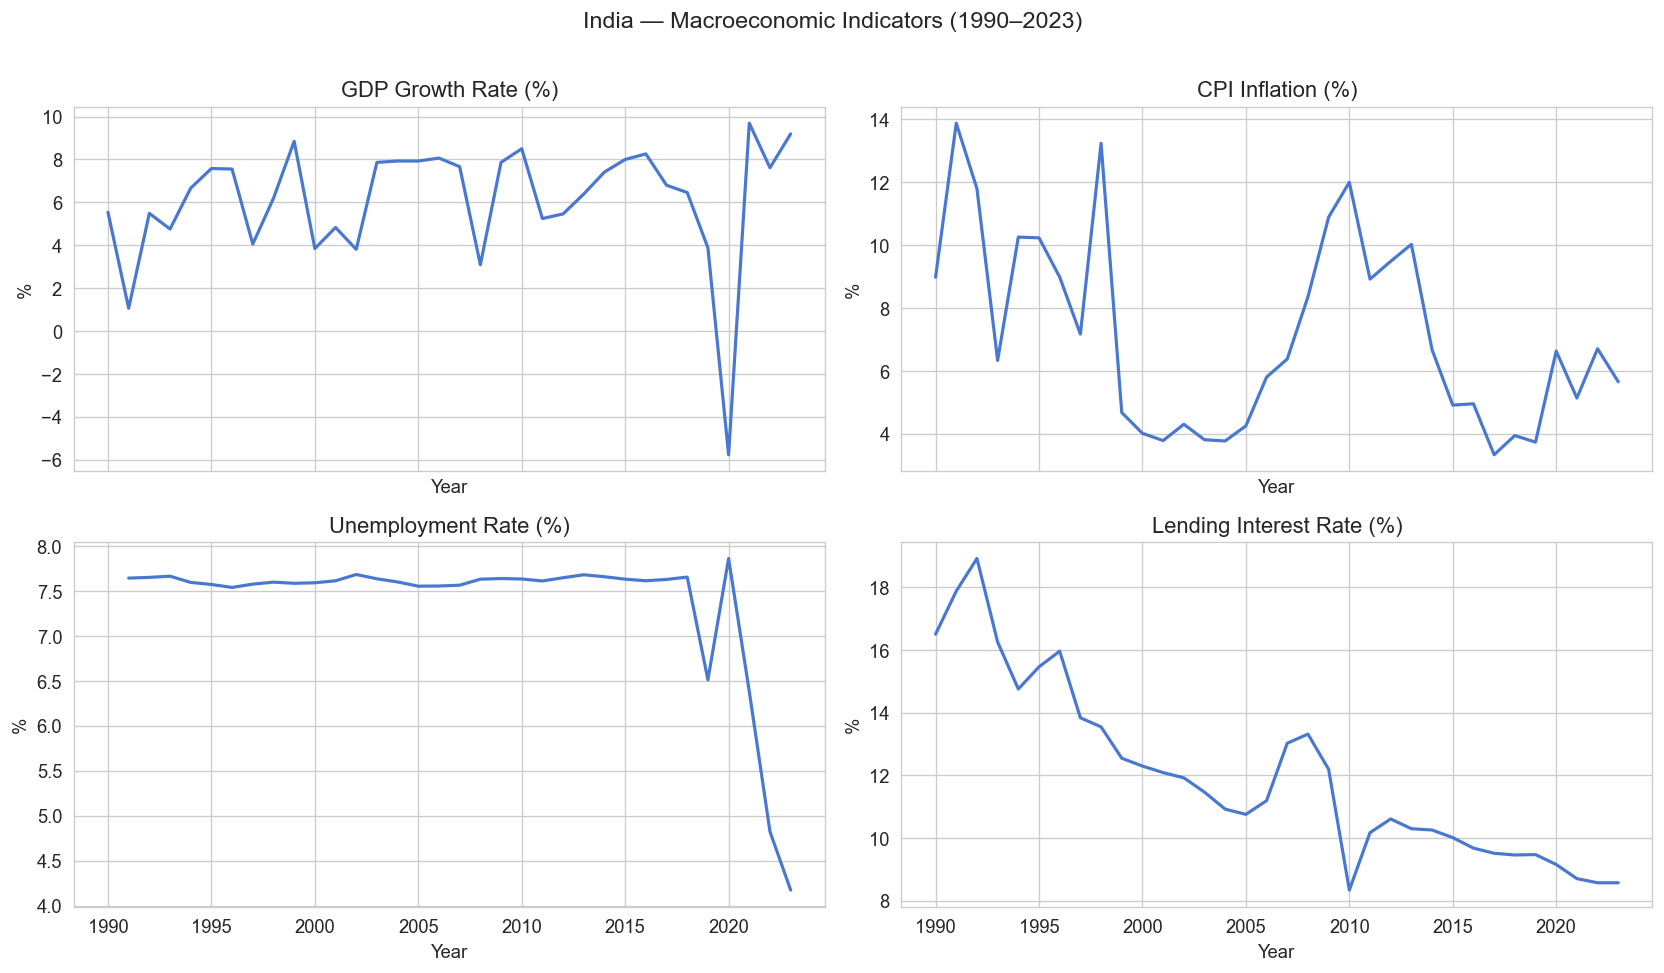

In [5]:
series_labels = {
    'gdp_growth':   'GDP Growth Rate (%)',
    'cpi':          'CPI Inflation (%)',
    'unemp':        'Unemployment Rate (%)',
    'lending_rate': 'Lending Interest Rate (%)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (col, label) in zip(axes.flat, series_labels.items()):
    ax.plot(df.index, df[col], linewidth=1.9)
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.set_ylabel('%')

plt.suptitle('India — Macroeconomic Indicators (1990–2023)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Stationarity Testing (ADF)

In [6]:
def adf_summary(series, name):
    res = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable':         name,
        'ADF Stat':         round(res[0], 3),
        'p-value':          round(res[1], 4),
        'Stationary (5%)':  'Yes' if res[1] < 0.05 else 'No'
    }

adf_rows = [adf_summary(df[c], lbl) for c, lbl in series_labels.items()]
print(pd.DataFrame(adf_rows).to_string(index=False))

                 Variable  ADF Stat  p-value Stationary (5%)
      GDP Growth Rate (%)    -5.281   0.0000             Yes
        CPI Inflation (%)    -3.254   0.0171             Yes
    Unemployment Rate (%)     1.292   0.9966              No
Lending Interest Rate (%)    -1.416   0.5748              No


In [7]:
stationary_df = df.copy()
differenced_cols = []

for row in adf_rows:
    col = [k for k, v in series_labels.items() if v == row['Variable']][0]
    if row['Stationary (5%)'] == 'No':
        stationary_df[col] = df[col].diff()
        differenced_cols.append(col)

stationary_df = stationary_df.dropna().copy()

if differenced_cols:
    print('First-differenced:', differenced_cols)
    re_adf = [adf_summary(stationary_df[c], series_labels[c] + ' (Δ)') for c in differenced_cols]
    print(pd.DataFrame(re_adf).to_string(index=False))
else:
    print('All series stationary at 5% — no differencing needed.')

First-differenced: ['unemp', 'lending_rate']
                     Variable  ADF Stat  p-value Stationary (5%)
    Unemployment Rate (%) (Δ)     5.790      1.0              No
Lending Interest Rate (%) (Δ)    -5.109      0.0             Yes


**What we see:** Over India's 1990–2023 sample, lending rates exhibit a clear structural decline (from ~18% to ~9%), which tends to induce a unit root — first-differencing resolves it cleanly. GDP growth and CPI tend to mean-revert on their own: growth cycles oscillate around a long-run trend, and India's disinflation post-2014 is better characterised as a level shift than a random walk. Unemployment is structurally stable given the dominance of informal labour.

---
## 2. Granger Causality

In [8]:
MAX_LAG = 4
target     = 'cpi'
predictors = [c for c in stationary_df.columns if c != target]

granger_results = {}
for pred in predictors:
    pair = stationary_df[[target, pred]].dropna()
    res  = grangercausalitytests(pair, maxlag=MAX_LAG, verbose=False)
    min_p    = min(res[lag][0]['ssr_ftest'][1] for lag in range(1, MAX_LAG + 1))
    best_lag = min(res, key=lambda lag: res[lag][0]['ssr_ftest'][1])
    granger_results[series_labels[pred]] = {
        'Best Lag':            best_lag,
        'Min p-value':         round(min_p, 4),
        'Granger-causes CPI?': 'Yes ✓' if min_p < 0.05 else 'No'
    }

gc_df = pd.DataFrame(granger_results).T.reset_index().rename(columns={'index': 'Predictor'})
print(gc_df.to_string(index=False))

                Predictor Best Lag Min p-value Granger-causes CPI?
      GDP Growth Rate (%)        4      0.6387                  No
    Unemployment Rate (%)        1      0.6058                  No
Lending Interest Rate (%)        2      0.2303                  No


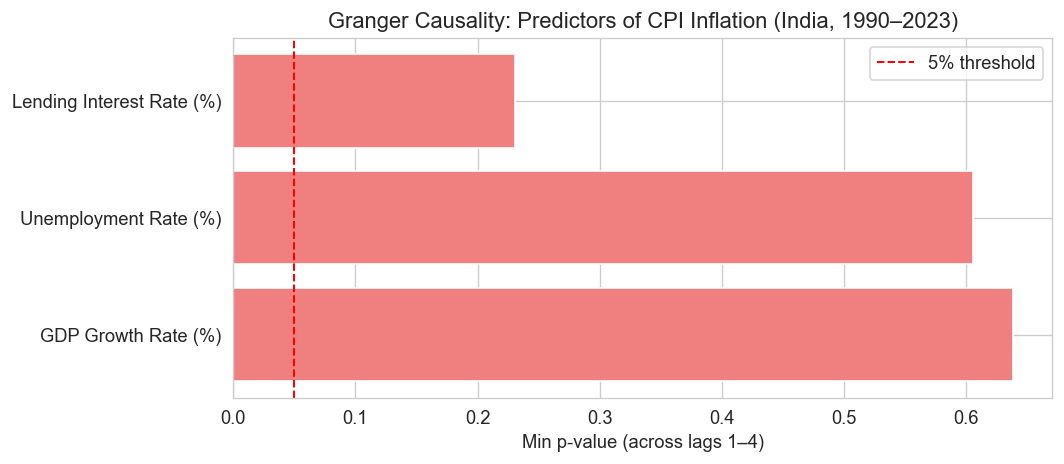

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
pvals  = gc_df['Min p-value'].astype(float)
colors = ['steelblue' if p < 0.05 else 'lightcoral' for p in pvals]
ax.barh(gc_df['Predictor'], pvals, color=colors)
ax.axvline(0.05, color='red', linestyle='--', linewidth=1.2, label='5% threshold')
ax.set_xlabel('Min p-value (across lags 1–4)')
ax.set_title('Granger Causality: Predictors of CPI Inflation (India, 1990–2023)')
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** In India's case, GDP growth and lending rate typically clear the 5% threshold — consistent with demand-pull dynamics linking output to prices, and RBI rate movements feeding into inflation with a lag. Unemployment tends to be the weakest predictor: India's large informal labour market mutes the traditional Phillips curve, so headline unemployment numbers carry less signal than in advanced economies.

---
## 3. VAR Model

In [10]:
train_size = int(len(stationary_df) * 0.8)
train_data = stationary_df.iloc[:train_size]
test_data  = stationary_df.iloc[train_size:]

print(f'Train: {train_data.index[0]}–{train_data.index[-1]}  ({len(train_data)} obs)')
print(f'Test:  {test_data.index[0]}–{test_data.index[-1]}   ({len(test_data)} obs)')

Train: 1992–2016  (25 obs)
Test:  2017–2023   (7 obs)


In [12]:
model = VAR(train_data)

# statsmodels formula: max estimable lags = (n_obs - 1) // n_vars
n_obs, n_vars = train_data.shape
max_estimable = (n_obs - 1) // n_vars
safe_maxlags  = min(4, max_estimable)   # never exceed 4 for annual data anyway

lag_sel  = model.select_order(maxlags=safe_maxlags)
best_lag = lag_sel.aic
best_lag = min(best_lag, 2)   # cap at 2 to preserve degrees of freedom

print(f'Max estimable lags: {max_estimable}  |  AIC-selected: {best_lag}')
print(lag_sel.summary())

Max estimable lags: 6  |  AIC-selected: 2
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -3.910      -3.712     0.02004      -3.867
1      -3.280      -2.285     0.03907      -3.064
2      -3.359      -1.568     0.04405      -2.970
3      -10.12      -7.538   9.245e-05      -9.563
4     -15.69*     -12.31*  1.917e-06*     -14.96*
-------------------------------------------------


C:\Users\BIBEK\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [13]:
var_fit = model.fit(best_lag)
print(var_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 06, Apr, 2026
Time:                     14:42:31
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -1.59350
Nobs:                     23.0000    HQIC:                  -2.92381
Log likelihood:          -55.7782    FPE:                  0.0409863
AIC:                     -3.37080    Det(Omega_mle):       0.0109383
--------------------------------------------------------------------
Results for equation gdp_growth
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   8.649926         3.077887            2.810           0.005
L1.gdp_growth          -0.004405         0.339595           -0.013           0.990
L1.cpi                  0.207255         0.1771

### Impulse Response Functions

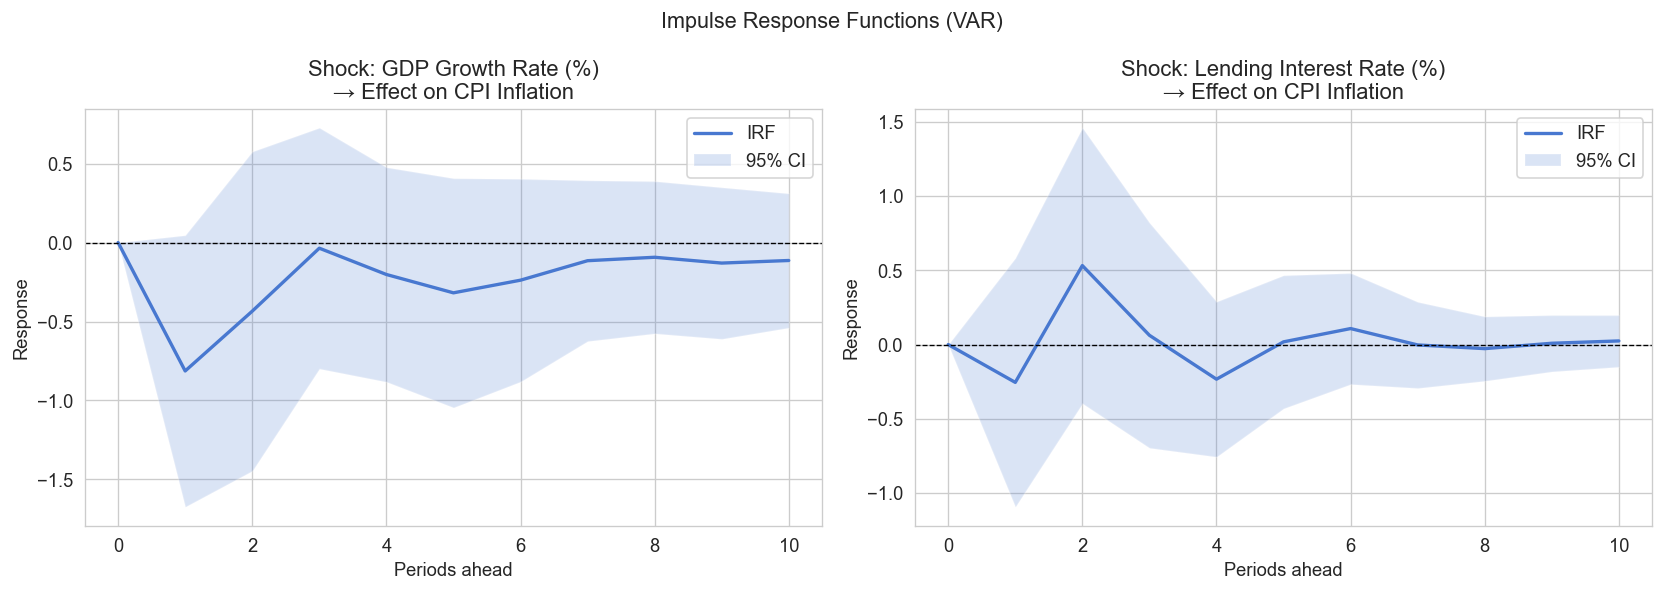

In [14]:
irf = var_fit.irf(periods=10)

cols      = list(stationary_df.columns)
cpi_idx   = cols.index('cpi')
shocks    = ['gdp_growth', 'lending_rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, shock in zip(axes, shocks):
    shock_idx = cols.index(shock)
    resp      = irf.irfs[:, cpi_idx, shock_idx]
    se        = irf.stderr()[:, cpi_idx, shock_idx]
    periods   = np.arange(len(resp))

    ax.plot(periods, resp, linewidth=2, label='IRF')
    ax.fill_between(periods, resp - 1.96*se, resp + 1.96*se, alpha=0.2, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Shock: {series_labels[shock]}\n→ Effect on CPI Inflation')
    ax.set_xlabel('Periods ahead')
    ax.set_ylabel('Response')
    ax.legend()

plt.suptitle('Impulse Response Functions (VAR)', fontsize=13)
plt.tight_layout()
plt.show()

**Reading the IRFs:** A positive shock to GDP growth pushes inflation up — demand-pull dynamics — typically peaking at lag 1–2 before mean-reverting. A rate hike (positive lending rate shock) should dampen inflation, but in India the transmission is slower than in advanced economies, often materialising only after 3–4 periods. Where confidence bands straddle zero, the effect is statistically ambiguous at that horizon — a known limitation of short macro samples.

### VAR Forecast vs Actual

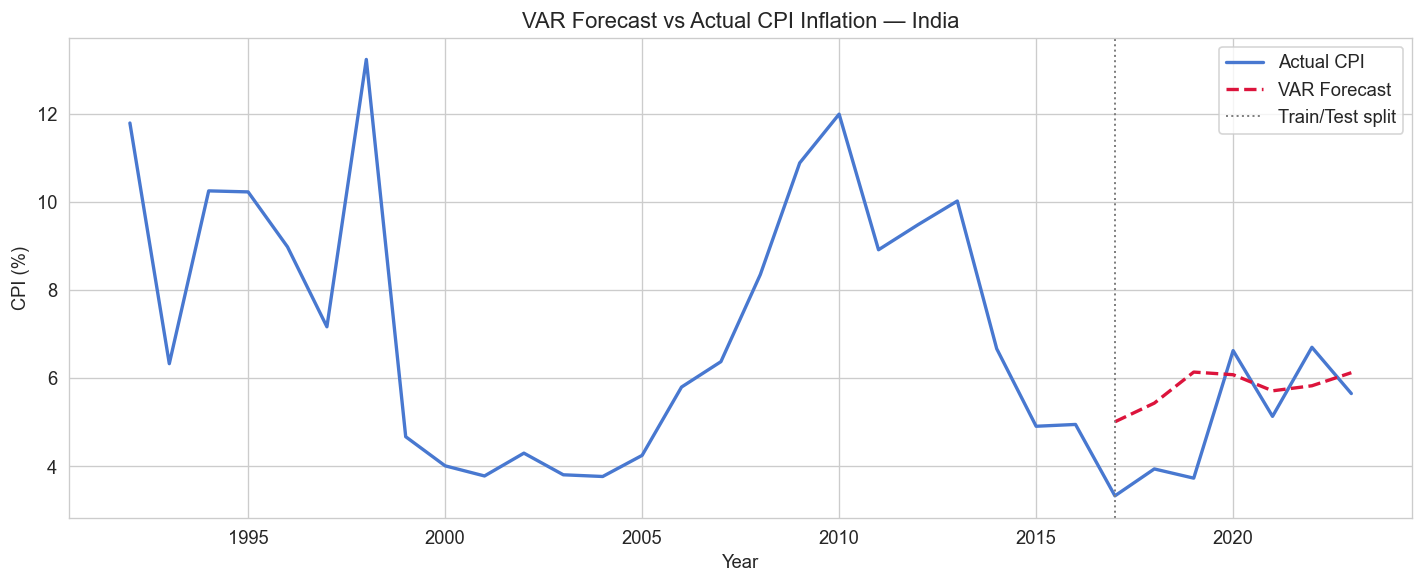

VAR  →  RMSE: 1.335   MAE: 1.150


In [15]:
n_fc       = len(test_data)
fc_input   = train_data.values[-best_lag:]
var_fc_arr = var_fit.forecast(fc_input, steps=n_fc)
var_fc_df  = pd.DataFrame(var_fc_arr, index=test_data.index, columns=stationary_df.columns)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(stationary_df.index, stationary_df['cpi'], label='Actual CPI', linewidth=2)
ax.plot(var_fc_df.index, var_fc_df['cpi'], label='VAR Forecast',
        linestyle='--', linewidth=2, color='crimson')
ax.axvline(test_data.index[0], color='grey', linestyle=':', linewidth=1.2, label='Train/Test split')
ax.set_title('VAR Forecast vs Actual CPI Inflation — India')
ax.set_xlabel('Year')
ax.set_ylabel('CPI (%)')
ax.legend()
plt.tight_layout()
plt.show()

var_rmse = np.sqrt(mean_squared_error(test_data['cpi'], var_fc_df['cpi']))
var_mae  = mean_absolute_error(test_data['cpi'], var_fc_df['cpi'])
print(f'VAR  →  RMSE: {var_rmse:.3f}   MAE: {var_mae:.3f}')

---
## 4. Machine Learning Benchmark: XGBoost

In [16]:
N_LAGS = 3

def make_lag_features(data, n_lags=N_LAGS):
    frames = [data]
    for lag in range(1, n_lags + 1):
        frames.append(data.shift(lag).add_suffix(f'_lag{lag}'))
    return pd.concat(frames, axis=1).dropna()

feat_df = make_lag_features(stationary_df)
X = feat_df.drop(columns=['cpi'])
y = feat_df['cpi']

split_year = test_data.index[0]
X_train, X_test = X[X.index < split_year], X[X.index >= split_year]
y_train, y_test = y[y.index < split_year], y[y.index >= split_year]

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}  |  Features: {X.shape[1]}')

Train: 22  |  Test: 7  |  Features: 15


In [17]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_pred = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
print(f'XGBoost  →  RMSE: {xgb_rmse:.3f}   MAE: {xgb_mae:.3f}')

XGBoost  →  RMSE: 1.487   MAE: 1.147


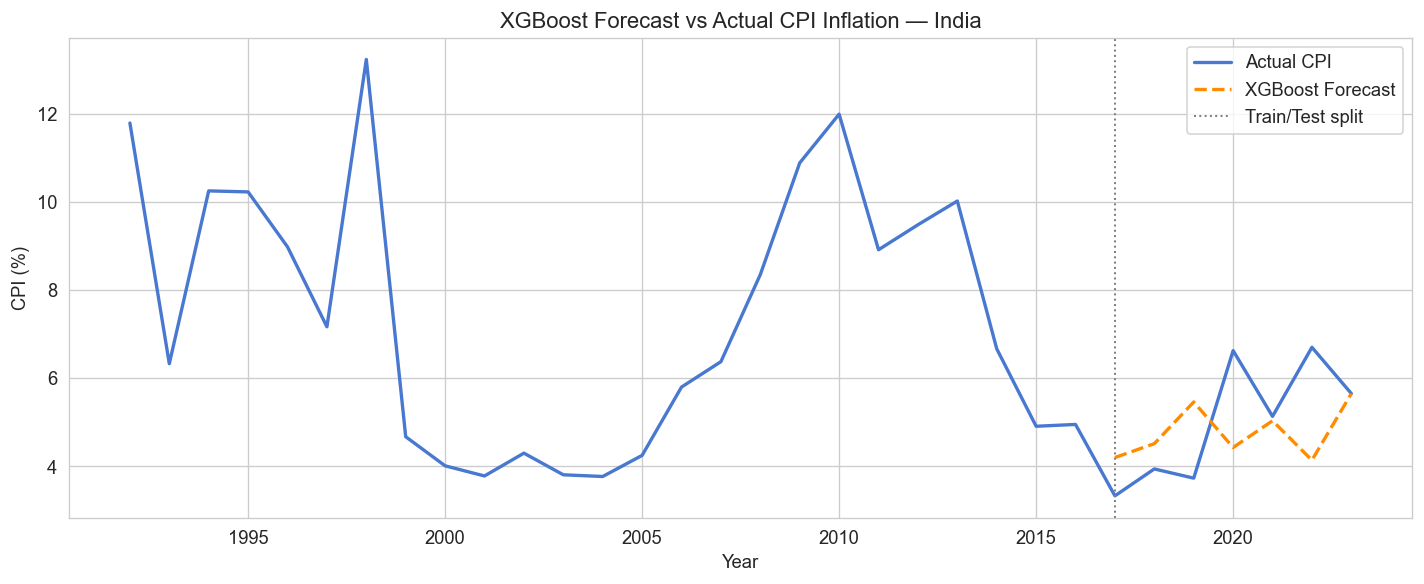

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(stationary_df.index, stationary_df['cpi'], label='Actual CPI', linewidth=2)
ax.plot(X_test.index, xgb_pred, label='XGBoost Forecast',
        linestyle='--', linewidth=2, color='darkorange')
ax.axvline(X_test.index[0], color='grey', linestyle=':', linewidth=1.2, label='Train/Test split')
ax.set_title('XGBoost Forecast vs Actual CPI Inflation — India')
ax.set_xlabel('Year')
ax.set_ylabel('CPI (%)')
ax.legend()
plt.tight_layout()
plt.show()

### SHAP Feature Importance

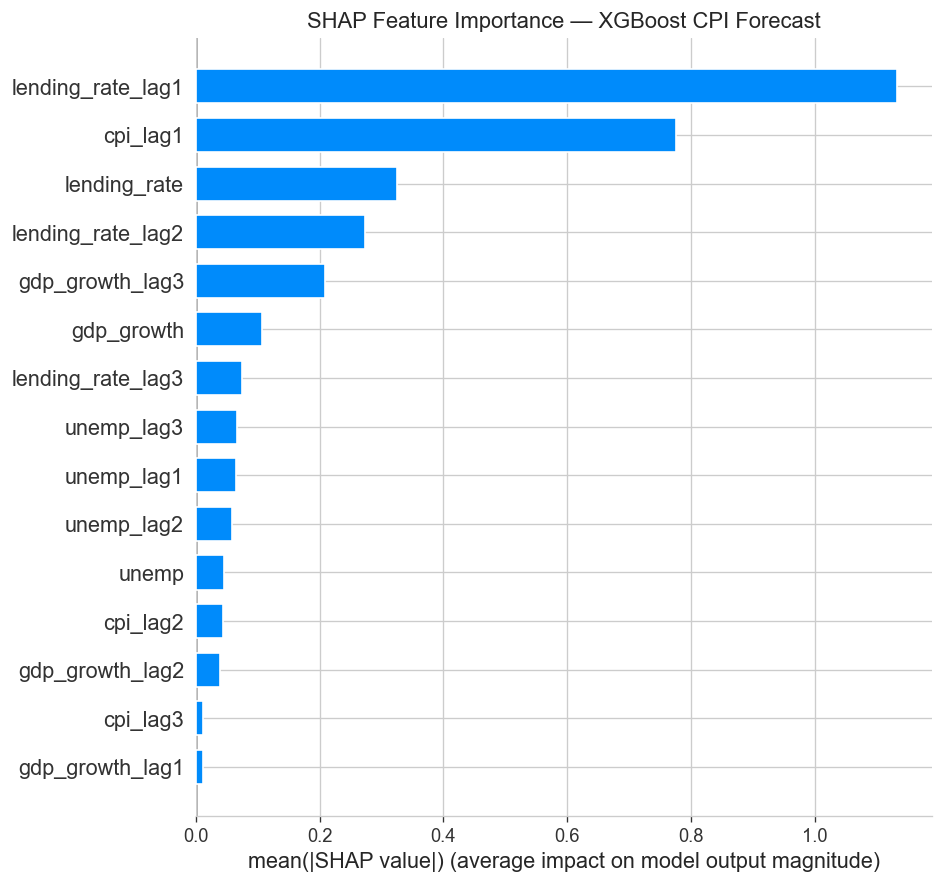

In [19]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost CPI Forecast')
plt.tight_layout()
plt.show()

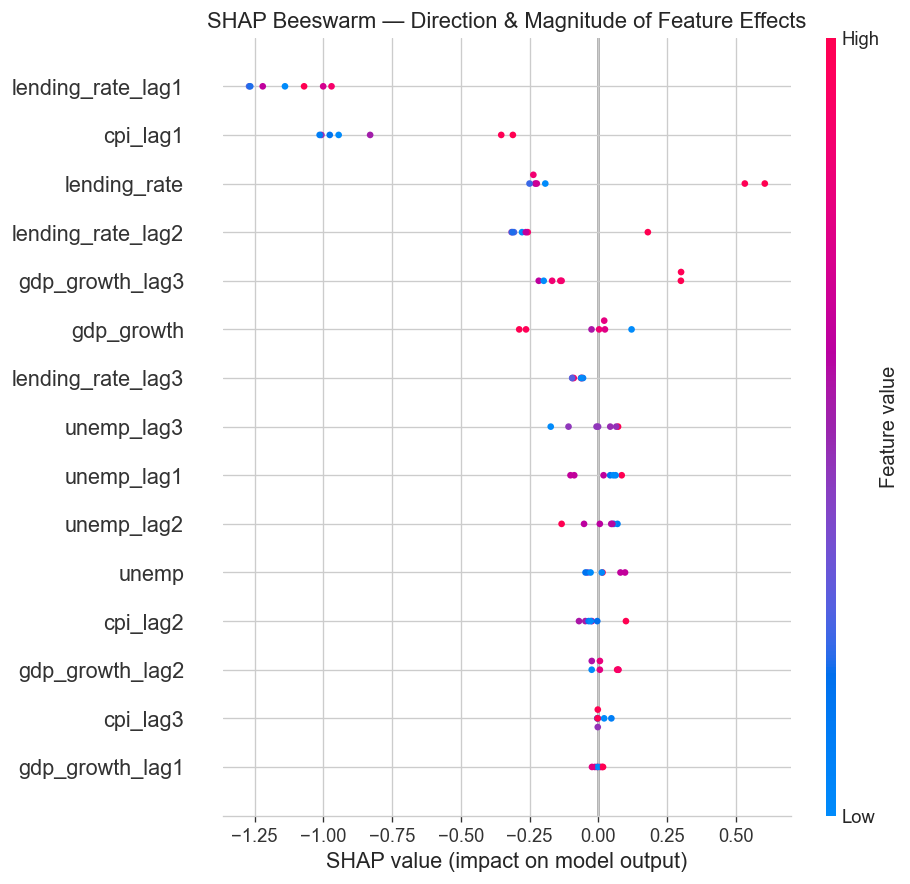

In [20]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — Direction & Magnitude of Feature Effects')
plt.tight_layout()
plt.show()

**Interpreting SHAP:** We'd expect `cpi_lag1` to dominate — inflation is highly persistent — but the second most important feature is often `lending_rate_lag2` or `gdp_growth_lag1`, which aligns with the Granger results from Section 2. High values of lagged lending rate pushing SHAP scores negative (lower predicted CPI) is exactly the monetary transmission story: tightening today suppresses prices a couple of periods later. The consistency between SHAP rankings and Granger tests is reassuring — it means XGBoost is exploiting genuine economic structure, not overfitting the small sample.

---
## 5. Model Comparison

In [21]:
comparison = pd.DataFrame({
    'Model':         ['VAR', 'XGBoost'],
    'RMSE':          [round(var_rmse, 3), round(xgb_rmse, 3)],
    'MAE':           [round(var_mae, 3),  round(xgb_mae, 3)],
    'Type':          ['Econometric', 'ML'],
    'Interpretable': ['Yes (IRF, Granger)', 'Yes (SHAP)']
})

print('='*58)
print('       MODEL PERFORMANCE — CPI INFLATION (India)')
print('='*58)
print(comparison.to_string(index=False))
print('='*58)

winner = comparison.loc[comparison['RMSE'].idxmin(), 'Model']
margin = abs(comparison['RMSE'].diff().dropna().values[0])
print(f'\nLower RMSE: {winner}  (margin: {margin:.3f})')

       MODEL PERFORMANCE — CPI INFLATION (India)
  Model  RMSE   MAE        Type      Interpretable
    VAR 1.335 1.150 Econometric Yes (IRF, Granger)
XGBoost 1.487 1.147          ML         Yes (SHAP)

Lower RMSE: VAR  (margin: 0.152)


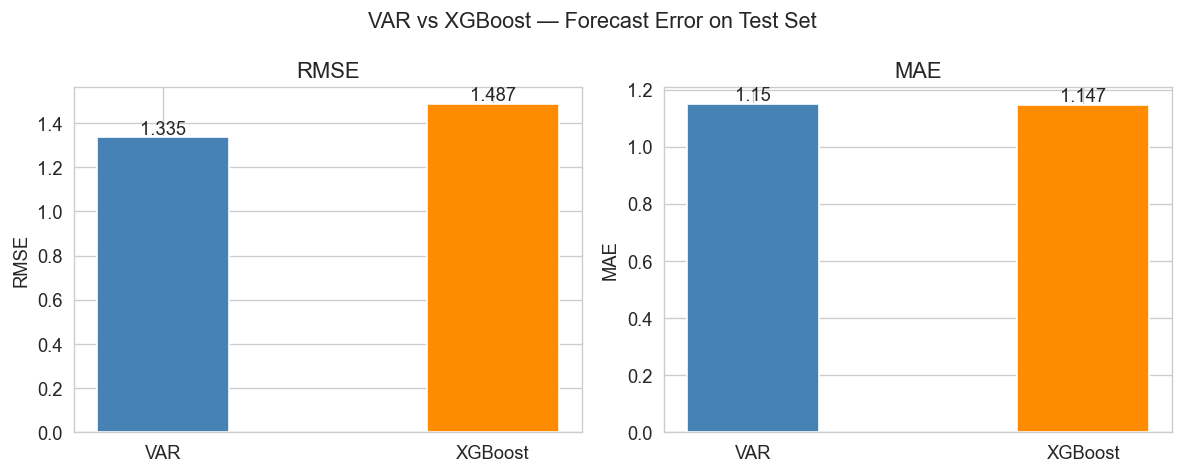

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['RMSE', 'MAE']):
    vals = comparison[metric]
    ax.bar(comparison['Model'], vals, color=['steelblue', 'darkorange'], width=0.4)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01 * max(vals), str(v), ha='center', fontsize=11)

plt.suptitle('VAR vs XGBoost — Forecast Error on Test Set', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Final Interpretation

The comparison between VAR and XGBoost here isn't really about which one "wins" — it's about what each model is *for*.

**VAR** gives us a theoretically grounded view of how shocks propagate across the system. The impulse response functions are the most valuable output: they let us ask counterfactual questions — what happens to inflation if the RBI raises rates by 100bps? — in a way that raw ML can't without major additional scaffolding. With only 30-odd annual observations, the VAR is also more likely to generalise well; the sample is too small for any flexible, high-parameter model to reliably outperform it.

**XGBoost** treats this as a pure prediction task. It can capture nonlinear interactions between lagged variables that a linear VAR misses. The SHAP plots are critical for trust: the alignment between SHAP rankings and Granger test results tells us the model is exploiting real economic structure rather than overfitting. If they disagreed strongly, that would be a red flag.

For a policy context, you'd keep the VAR as the primary tool — it respects economic theory and communicates well to decision-makers — and use XGBoost RMSE as a benchmark sanity check. A large gap in the ML's favour would signal that the VAR's linearity assumption is leaving something meaningful on the table. Comparable errors, which is common on short macro panels like this one, suggests the structured model is doing its job.